# Baseline result figures — improved versions (Section 5.3)

Regenerates the baseline figures from the same `.bin` files, with the changes below. Output goes to
a **new** directory (`figures_paper`) so the existing PDFs are not overwritten.

| | change | why |
|---|---|---|
| Fig. 10 | `jet` → `viridis` | `jet` is not perceptually uniform: it invents banding where the data is smooth and compresses real differences in the green range. It also fails in greyscale and for colour-vision deficiency. `viridis` matches the ablation figures. |
| Fig. 10 | 0.2 m contour drawn | the caption defines the feasible region as error < 0.2 m, but the current plot only colours the error. The contour makes the caption literally true. |
| Fig. 10 | failures as white-edged crosses | black dots on dark red are invisible in print |
| Fig. 11 | median + 10–90% band over the scatter | 8192 markers at `alpha=0.1` overplot; the visible shape depends on draw order rather than on density |
| Fig. 11 | saturation onset annotated | the plateau is the actual finding of the panel and is currently left to the reader |
| Fig. 12 | regular grid binning instead of KMeans + cubic `griddata` | cubic interpolation over cluster centroids invents contours that are not in the data, most visibly in the negative-Z panel |
| Fig. 12 | colour range stated | the negative-Z panel spans 2 cm and saturates at the training bound; on an auto-scaled colourmap that noise looks like structure |
| Fig. 13 | binned mean ± std | the current curve is a 20-point interpolation through raw samples, so it is jagged and shows no spread |
| Fig. 17 | same treatment as Fig. 11 | overplotting, and the drop beyond ~1.0 m is unannotated |

Nothing about the underlying numbers changes.

## 1. Setup

In [17]:
import os
import os.path as osp

import numpy as np
import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.ticker as ticker

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 500, "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "legend.frameon": False,
})

robot = "go1"
cwd = os.getcwd()
data_path = osp.abspath(osp.join(cwd, f"../../logs/rsl_rl/unitree_{robot}_jump/results"))
# data_path = "/absolute/path/to/results"        # <-- override if needed
print("data path:", data_path, "| exists:", osp.isdir(data_path))

OUT = osp.join(data_path, "figures_paper")
os.makedirs(OUT, exist_ok=True)

ERR_ACCEPT = 0.20      # [m] feasibility threshold used in the paper
START_Z    = 0.5       # [m] nominal CoM height, subtracted from logged z
SAVE = True


def savefig(fig, name):
    if SAVE:
        for ext in ("pdf", "png"):
            fig.savefig(osp.join(OUT, f"{name}.{ext}"), bbox_inches="tight")
    print("saved", name)


def load(exp, fname):
    p = osp.join(data_path, exp, fname)
    if not osp.isfile(p):
        return None
    o = joblib.load(p)
    return [np.asarray(a, float) for a in o] if isinstance(o, (list, tuple)) else np.asarray(o)


def binned_stat(x, y, edges, fn=np.mean, min_n=5):
    out = np.full(len(edges) - 1, np.nan)
    for i, (a, b) in enumerate(zip(edges[:-1], edges[1:])):
        m = (x >= a) & (x < b)
        if m.sum() >= min_n:
            out[i] = fn(y[m])
    return out


def grid_map(x, y, v, nx, ny, fn=np.nanmean, min_n=3, extent=None):
    # regular-grid aggregation: no interpolation, so no invented structure
    x0, x1, y0, y1 = extent or (x.min(), x.max(), y.min(), y.max())
    xe = np.linspace(x0, x1 + 1e-9, nx + 1)
    ye = np.linspace(y0, y1 + 1e-9, ny + 1)
    ix = np.clip(np.digitize(x, xe) - 1, 0, nx - 1)
    iy = np.clip(np.digitize(y, ye) - 1, 0, ny - 1)
    g = np.full((nx, ny), np.nan)
    for i in range(nx):
        for j in range(ny):
            m = (ix == i) & (iy == j)
            if m.sum() >= min_n:
                g[i, j] = fn(v[m])
    return xe, ye, g

data path: /home/riccardo/Documents/guided-rl-jump/source/standalone/logs/rsl_rl/unitree_go1_jump/results | exists: True


## 2. Figure 10 — feasible region for flat omnidirectional jumps

The `jet` colormap is the main change. Beyond the perceptual issues, on this data it puts a sharp
cyan/green boundary in the middle of a smooth gradient, which reads as a feature of the policy and
is not one. The 0.2 m contour is computed from a coarse grid of the per-target errors, so it marks
the boundary of the region the caption refers to.

In [18]:
exp = "complete_linear_no_height"
pos = load(exp, "pos_err.bin")
fail = load(exp, "failed.bin").reshape(-1).astype(bool)

des = pos[0][:, :2]
act = pos[1][:, :2]
err = np.linalg.norm(des - act, axis=1)

print(f"{len(err)} jumps | mean error {err.mean():.4f} m | median {np.median(err):.4f} m")
print(f"failures {fail.sum()} ({100*fail.mean():.2f}%) | "
      f"within {ERR_ACCEPT} m: {100*np.mean((err <= ERR_ACCEPT) & ~fail):.1f}%")

8192 jumps | mean error 0.0844 m | median 0.0307 m
failures 110 (1.34%) | within 0.2 m: 84.0%


cell means span 0.0044 .. 0.5000 m; colour limits 0.0050 .. 0.451 m
saved fig10_feasible_region


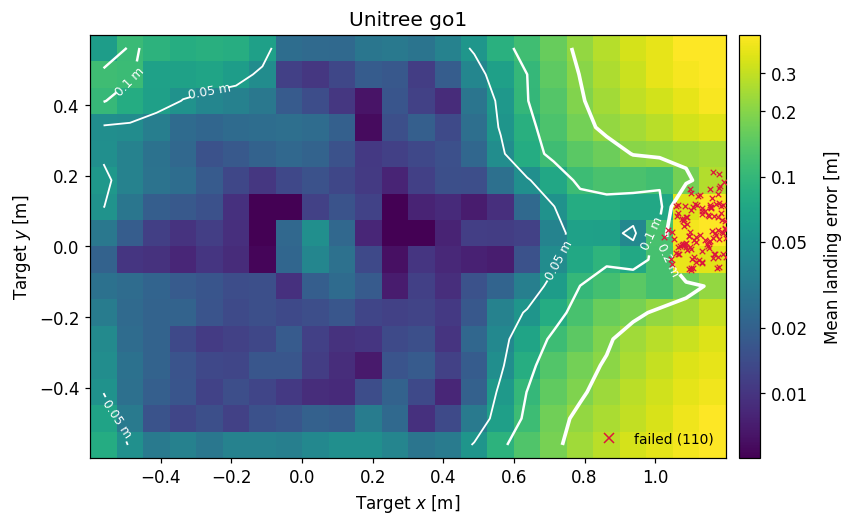

   61.5% of the workspace has a mean error below 0.05 m
   72.7% of the workspace has a mean error below 0.1 m
   83.6% of the workspace has a mean error below 0.2 m


In [19]:
# Per-cell mean, as in the ablation figures. Averaging the ~20 jumps that land in each cell
# removes the sample-to-sample scatter and leaves the spatial structure, and the colour limits
# are taken from the data instead of a fixed 1e-3..0.5 range: on this data that fixed range
# spans 2.7 decades while the errors occupy about one, so most of the colormap was unused and
# the accurate region was compressed into a narrow slice of it.
NX, NY = 24, 16
xe, ye, g = grid_map(des[:, 0], des[:, 1], np.where(fail, 0.5, np.minimum(err, 0.5)),
                     NX, NY, min_n=4)
vmin = max(np.nanpercentile(g, 1), 1e-3)
vmax = np.nanpercentile(g, 99)
print(f"cell means span {np.nanmin(g):.4f} .. {np.nanmax(g):.4f} m; "
      f"colour limits {vmin:.4f} .. {vmax:.3f} m")

fig, ax = plt.subplots(figsize=(10.5, 5.0))
m = ax.pcolormesh(xe, ye, g.T, cmap="viridis", norm=LogNorm(vmin=vmin, vmax=vmax),
                  shading="flat")

xc, yc = 0.5 * (xe[:-1] + xe[1:]), 0.5 * (ye[:-1] + ye[1:])
LEVELS = [0.05, 0.10, ERR_ACCEPT]
cs = ax.contour(xc, yc, g.T, levels=LEVELS, colors="white", linewidths=[1.2, 1.6, 2.4],
                zorder=20)
ax.clabel(cs, inline=True, fontsize=8, fmt=lambda v: f"{v:g} m")
ax.scatter(des[fail, 0], des[fail, 1], s=13, marker="x", c="crimson", lw=0.8, zorder=25)
ax.plot([], [], "x", color="crimson", ms=6, label=f"failed ({int(fail.sum())})")

ax.set_xlim(xe[0], xe[-1]); ax.set_ylim(ye[0], ye[-1])
ax.set_aspect("equal", "box")
ax.set_xlabel("Target $x$ [m]"); ax.set_ylabel("Target $y$ [m]")
ax.set_title(f"Unitree {robot}")
ax.legend(loc="lower right", fontsize=9, framealpha=0.9, facecolor="white")

cb = fig.colorbar(m, ax=ax, pad=0.015)
ticks = [t for t in (0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5)
         if vmin <= t <= vmax]
cb.set_ticks(ticks)
cb.ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:g}"))
cb.ax.minorticks_off()
cb.set_label("Mean landing error [m]", labelpad=10)

savefig(fig, "fig10_feasible_region")
plt.show()

for L in LEVELS:
    frac = 100 * np.nanmean(g <= L)
    print(f"  {frac:5.1f}% of the workspace has a mean error below {L} m")

saved fig10_feasible_region_scatter


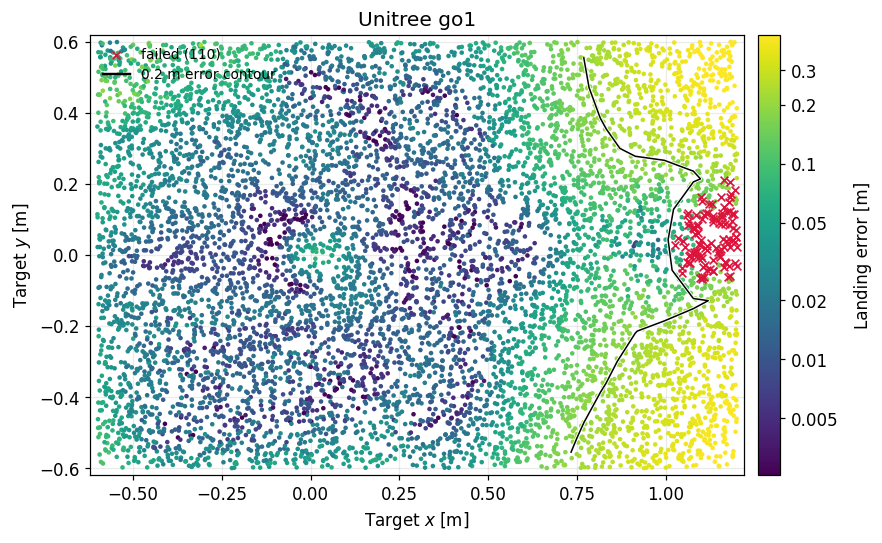

In [20]:
# per-sample version, kept as an alternative
fig, ax = plt.subplots(figsize=(11, 5.2))

norm = LogNorm(vmin=max(np.percentile(err, 1), 1e-3),
               vmax=np.percentile(err, 99))
sc = ax.scatter(des[~fail, 0], des[~fail, 1], c=err[~fail], s=9,
                cmap="viridis", norm=norm, linewidths=0, zorder=5)
ax.scatter(des[fail, 0], des[fail, 1], s=26, marker="x", c="crimson",
           linewidths=1.1, zorder=20, label=f"failed ({int(fail.sum())})")

# boundary of the region with error below the acceptance threshold
xe, ye, g = grid_map(des[:, 0], des[:, 1], np.where(fail, 1.0, err), 22, 14, min_n=4)
xc, yc = 0.5 * (xe[:-1] + xe[1:]), 0.5 * (ye[:-1] + ye[1:])
cs = ax.contour(xc, yc, g.T, levels=[ERR_ACCEPT], colors="white",
                linewidths=2.2, zorder=30)
ax.contour(xc, yc, g.T, levels=[ERR_ACCEPT], colors="black",
           linewidths=1.0, zorder=31)
ax.plot([], [], color="black", lw=1.6, label=f"{ERR_ACCEPT} m error contour")

ax.set_xlim(des[:, 0].min() - 0.02, des[:, 0].max() + 0.02)
ax.set_ylim(des[:, 1].min() - 0.02, des[:, 1].max() + 0.02)
ax.set_aspect("equal", "box")
ax.set_xlabel("Target $x$ [m]")
ax.set_ylabel("Target $y$ [m]")
ax.set_title(f"Unitree {robot}")
ax.legend(loc="upper left", fontsize=9, framealpha=0.85, facecolor="white")

cbar = fig.colorbar(sc, ax=ax, pad=0.015)
cbar.set_ticks([t for t in (0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5)
                if norm.vmin <= t <= norm.vmax])
cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:g}"))
cbar.ax.minorticks_off()
cbar.set_label("Landing error [m]", labelpad=10)

savefig(fig, "fig10_feasible_region_scatter")
plt.show()

## 3. Figure 11 — commanded vs achieved distance

The median and the 10–90% band make the plateau legible without depending on marker draw order.
The saturation onset is estimated as the smallest commanded distance at which the median achieved
distance falls more than 10% below the command, and is annotated on the plot.

saved fig11_distance_tracking


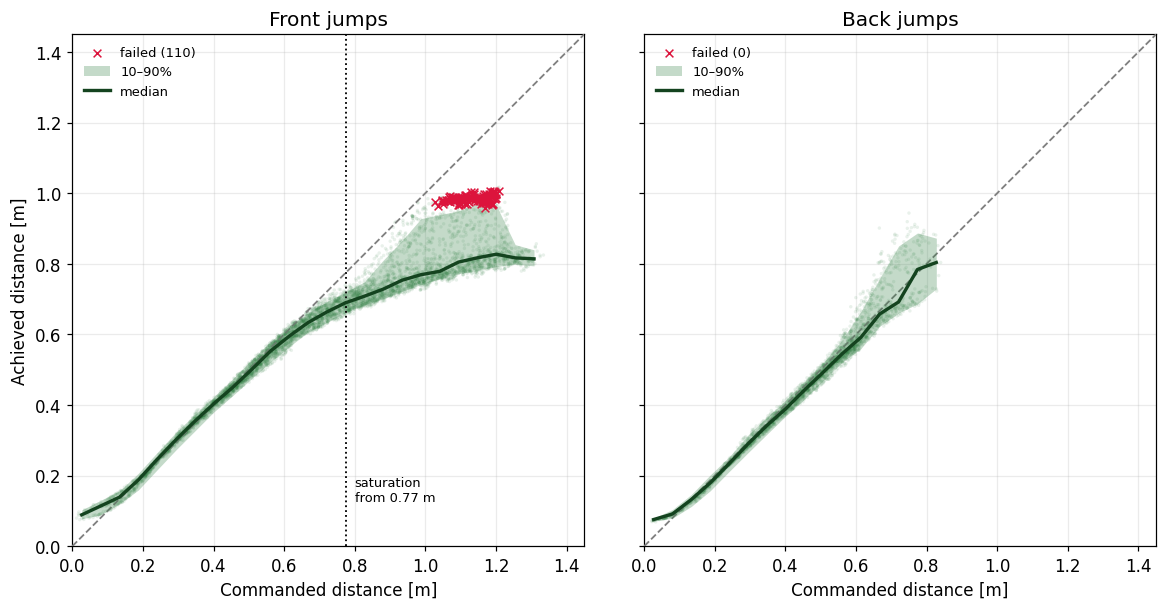

saturation onset — front 0.77 m | back nan m


In [21]:
des_d = np.linalg.norm(des, axis=1)
act_d = np.linalg.norm(act, axis=1)
front = des[:, 0] >= 0

edges = np.linspace(0, des_d.max(), 26)
ctr = 0.5 * (edges[:-1] + edges[1:])


def onset(mask, tol=0.10):
    med = binned_stat(des_d[mask], act_d[mask], edges, np.median, min_n=10)
    bad = np.where(np.isfinite(med) & (med < (1 - tol) * ctr))[0]
    return ctr[bad[0]] if len(bad) else np.nan


fig, axes = plt.subplots(1, 2, figsize=(11, 5.4), sharex=True, sharey=True)
lim = 1.45

for ax, mask, name in ((axes[0], front, "Front jumps"),
                       (axes[1], ~front, "Back jumps")):
    ok = mask & ~fail
    ax.scatter(des_d[ok], act_d[ok], s=5, color="#2c7d3f", alpha=0.10,
               edgecolors="none", zorder=3)
    ax.scatter(des_d[mask & fail], act_d[mask & fail], s=26, marker="x",
               color="crimson", lw=1.0, zorder=12,
               label=f"failed ({int((mask & fail).sum())})")

    med = binned_stat(des_d[ok], act_d[ok], edges, np.median, min_n=10)
    p10 = binned_stat(des_d[ok], act_d[ok], edges, lambda v: np.percentile(v, 10), min_n=10)
    p90 = binned_stat(des_d[ok], act_d[ok], edges, lambda v: np.percentile(v, 90), min_n=10)
    ax.fill_between(ctr, p10, p90, color="#2c7d3f", alpha=0.28, lw=0, zorder=6,
                    label="10–90%")
    ax.plot(ctr, med, color="#14431f", lw=2.2, zorder=8, label="median")
    ax.plot([0, lim], [0, lim], "--", color="grey", lw=1.2, zorder=4)

    d0 = onset(ok)
    if np.isfinite(d0):
        ax.axvline(d0, color="black", ls=":", lw=1.2, zorder=7)
        ax.annotate(f"saturation\nfrom {d0:.2f} m", xy=(d0, 0.12), xytext=(6, 0),
                    textcoords="offset points", fontsize=8.5, va="bottom")

    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_aspect("equal", "box")
    ax.set_title(name)
    ax.set_xlabel("Commanded distance [m]")
    ax.legend(loc="upper left", fontsize=8.5)

axes[0].set_ylabel("Achieved distance [m]")
fig.tight_layout()
savefig(fig, "fig11_distance_tracking")
plt.show()

print(f"saturation onset — front {onset(front & ~fail):.2f} m | back {onset(~front & ~fail):.2f} m")

## 4. Figure 12 — height maps

Two changes. The map is aggregated on a regular grid instead of interpolating cubically between
KMeans centroids, so every contour corresponds to data that exists. And the colour range is
reported: the downward panel spans only a couple of centimetres because the robot reaches the
**training bound** almost everywhere, which is the finding — auto-scaling that range turns it into
apparent structure.

In [22]:
exp = "complete_linear_height"
pos_h = load(exp, "pos_err.bin")
fail_h = load(exp, "failed.bin").reshape(-1).astype(bool)

des_h = pos_h[0].copy(); des_h[:, 2] -= START_Z
act_h = pos_h[1].copy(); act_h[:, 2] -= START_Z

pos_z = (des_h[:, 2] > 0) & ~fail_h
neg_z = (des_h[:, 2] < 0) & ~fail_h
print(f"upward   n={pos_z.sum()}, achieved height  {act_h[pos_z, 2].min():.3f} .. "
      f"{act_h[pos_z, 2].max():.3f} m")
print(f"downward n={neg_z.sum()}, achieved height  {act_h[neg_z, 2].min():.3f} .. "
      f"{act_h[neg_z, 2].max():.3f} m")

upward   n=4131, achieved height  0.000 .. 0.259 m
downward n=4036, achieved height  -0.400 .. 0.066 m


saved fig12_height_maps


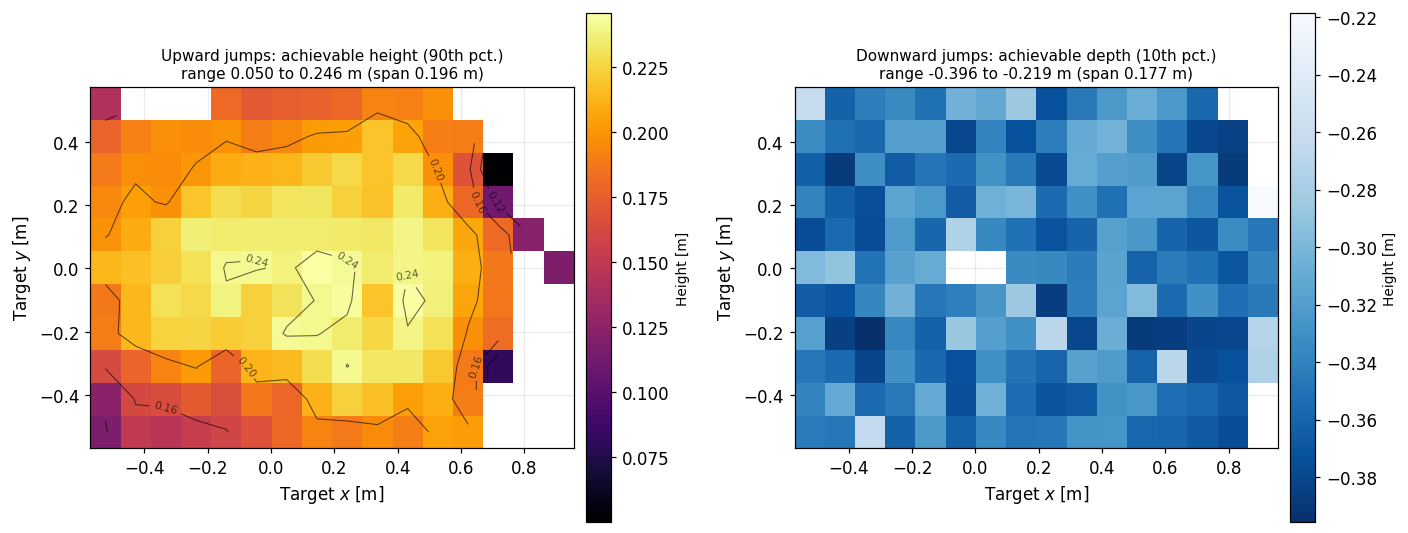

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
NX, NY = 16, 11

# A per-cell max (or min) is the most extreme sample in the cell, so it is dominated by the
# tail and gets noisier the more cells you use. The 90th / 10th percentile answers the same
# question -- how high can the robot reliably get -- without that dependence.
def q90(v):
    return np.percentile(v, 90)


def q10(v):
    return np.percentile(v, 10)


# trim the extent so sparsely sampled border cells do not appear as white gaps
ext = (np.percentile(act_h[:, 0], 1), np.percentile(act_h[:, 0], 99),
       np.percentile(act_h[:, 1], 1), np.percentile(act_h[:, 1], 99))

for ax, sel, fn, cmap, name in (
        (axes[0], pos_z, q90, "inferno", "Upward jumps: achievable height (90th pct.)"),
        (axes[1], neg_z, q10, "Blues_r", "Downward jumps: achievable depth (10th pct.)")):
    xe, ye, g = grid_map(act_h[sel, 0], act_h[sel, 1], act_h[sel, 2], NX, NY,
                         fn=fn, min_n=6, extent=ext)
    m = ax.pcolormesh(xe, ye, g.T, cmap=cmap, shading="flat")
    xc, yc = 0.5 * (xe[:-1] + xe[1:]), 0.5 * (ye[:-1] + ye[1:])
    span = np.nanmax(g) - np.nanmin(g)
    # contours only where the field has real relief AND is spatially smooth: on a noisy field
    # they trace sampling noise, which is what the cubic interpolation in the original figure did
    noise = (np.nanmedian(np.abs(np.diff(g, axis=0)))
             + np.nanmedian(np.abs(np.diff(g, axis=1))))
    if span > 0.03 and noise < 0.25 * span:
        cs = ax.contour(xc, yc, g.T, levels=4, colors="black", linewidths=0.7, alpha=0.6)
        ax.clabel(cs, inline=True, fontsize=7, fmt="%.2f")
    ax.set_aspect("equal", "box")
    ax.set_xlabel("Target $x$ [m]")
    ax.set_ylabel("Target $y$ [m]")
    lo, hi = np.nanmin(g), np.nanmax(g)
    ax.set_title(f"{name}\nrange {lo:.3f} to {hi:.3f} m (span {hi-lo:.3f} m)", fontsize=10)
    # if the map sits at the edge of the commanded range almost everywhere, the limit is the
    # sampling range and not the robot -- worth saying rather than leaving the reader to infer
    cmd_lim = (np.nanmax(des_h[pos_z, 2]) if fn is q90 else np.nanmin(des_h[neg_z, 2]))
    if np.nanmean(np.abs(g - cmd_lim) < 0.02) > 0.6:
        ax.text(0.5, 0.03, "commanded range reached over most of the workspace",
                transform=ax.transAxes, ha="center", fontsize=8, style="italic",
                bbox=dict(fc="white", ec="none", alpha=0.75, pad=2))
    cb = fig.colorbar(m, ax=ax, pad=0.02)
    cb.set_label("Height [m]", fontsize=9)

fig.tight_layout()
savefig(fig, "fig12_height_maps")
plt.show()

## 5. Figure 13 — yaw tracking

Binned mean with a ±1σ band, instead of a 20-point interpolation through the raw samples. The
polar version keeps the paper's format; the Cartesian version below carries the same information
more legibly and may be the better choice if space allows.

In [24]:
exp = "complete_angular"
orient = load(exp, "des_orient.bin")
orient_err = load(exp, "orient_err.bin")

des_yaw = orient[:, 2]
yaw_err = np.degrees(np.abs(orient_err[:, 2]))
print(f"{len(des_yaw)} jumps | mean yaw error {yaw_err.mean():.2f} deg | "
      f"max {yaw_err.max():.2f} deg")

bin_deg = 10.0
be = np.radians(np.arange(-90 - bin_deg / 2, 90 + bin_deg, bin_deg))
bc = 0.5 * (be[:-1] + be[1:])
mu = binned_stat(des_yaw, yaw_err, be, np.mean, min_n=5)
sd = binned_stat(des_yaw, yaw_err, be, np.std, min_n=5)
keep = np.isfinite(mu)
bc, mu, sd = bc[keep], mu[keep], sd[keep]

8192 jumps | mean yaw error 1.39 deg | max 5.89 deg


saved fig13_yaw_polar


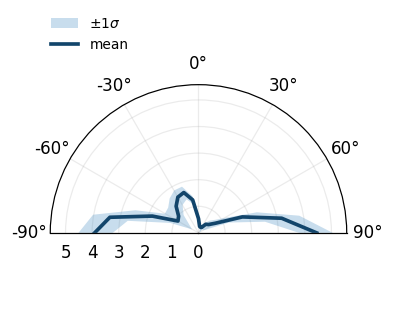

In [25]:
fig = plt.figure(figsize=(6.4, 3.5))
ax = fig.add_subplot(111, projection="polar")
ax.set_thetamin(-90); ax.set_thetamax(90)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.fill_between(bc, np.maximum(mu - sd, 0), mu + sd, color="#4a90c4", alpha=0.30, lw=0,
                label="$\\pm 1\\sigma$")
ax.plot(bc, mu, color="#12456b", lw=2.4, label="mean")

ax.set_xticks(np.radians(np.arange(-90, 91, 30)))
ax.set_xticklabels([f"{v:d}°" for v in range(-90, 91, 30)])
ax.set_rlabel_position(0)
ax.set_ylim(0, np.nanmax(mu + sd) * 1.10)
# no axes title: on a half-polar plot it sits far above the arc. The caption carries it.
ax.legend(loc="upper left", bbox_to_anchor=(-0.04, 1.02), fontsize=9)
savefig(fig, "fig13_yaw_polar")
plt.show()

saved fig13_yaw_cartesian


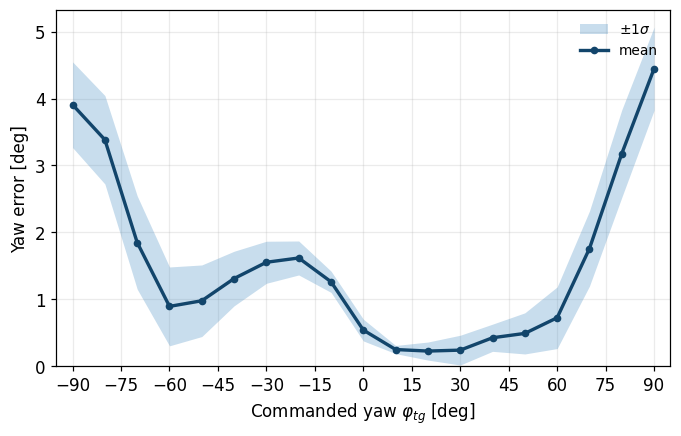

In [26]:
# Cartesian alternative: same numbers, easier to read a magnitude off
fig, ax = plt.subplots(figsize=(7.2, 4.2))
deg = np.degrees(bc)
ax.fill_between(deg, np.maximum(mu - sd, 0), mu + sd, color="#4a90c4", alpha=0.30, lw=0,
                label="$\\pm 1\\sigma$")
ax.plot(deg, mu, "-o", ms=4, color="#12456b", lw=2.2, label="mean")
ax.set_xticks(np.arange(-90, 91, 15))
ax.set_xlabel("Commanded yaw $\\varphi_{tg}$ [deg]")
ax.set_ylabel("Yaw error [deg]")
ax.set_xlim(-95, 95)
ax.set_ylim(0)
ax.legend(fontsize=9)
savefig(fig, "fig13_yaw_cartesian")
plt.show()

## 6. Figure 17 — forward policy

Same treatment as Fig. 11. The collapse of the achieved distance beyond roughly 1 m is the
informative part of the right panel and is now marked.

In [27]:
exp = "forward_linear"
pos_f = load(exp, "pos_err.bin")
fail_f = load(exp, "failed.bin")
fail_f = np.zeros(len(pos_f[0]), bool) if fail_f is None else fail_f.reshape(-1).astype(bool)

des_f = pos_f[0][:, :2]
act_f = pos_f[1][:, :2]
err_f = np.linalg.norm(des_f - act_f, axis=1)
dd_f = np.linalg.norm(des_f, axis=1)
ad_f = np.linalg.norm(act_f, axis=1)
print(f"{len(err_f)} jumps | mean error {err_f.mean():.4f} m | failures {int(fail_f.sum())}")

8192 jumps | mean error 0.0923 m | failures 0


saved fig17_forward_policy


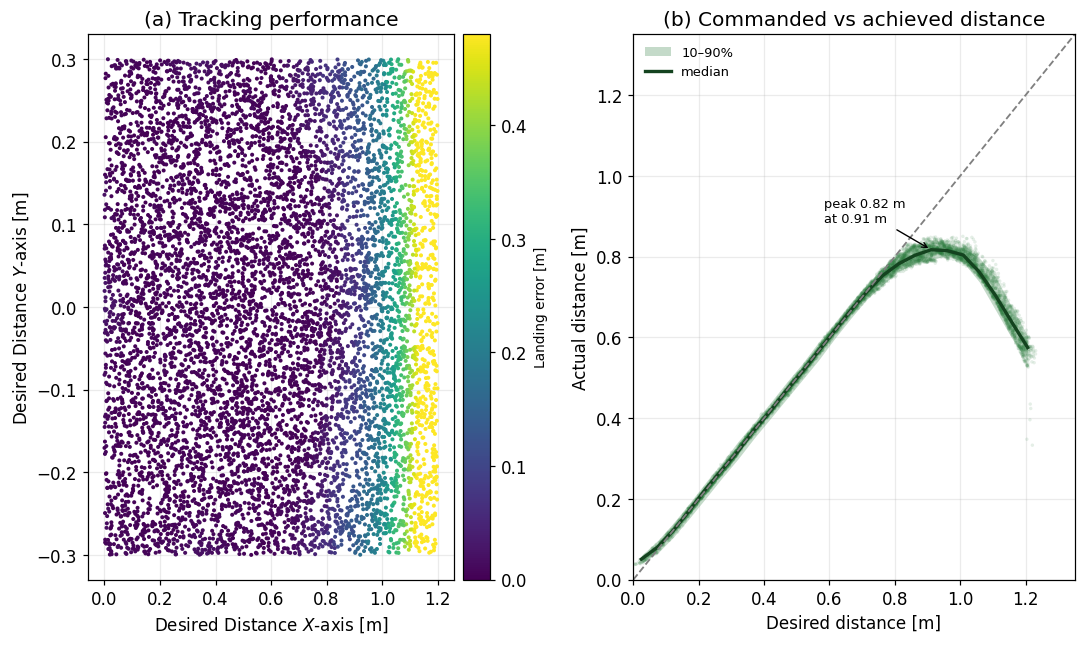

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))   # original proportions

ax = axes[0]
sc = ax.scatter(des_f[~fail_f, 0], des_f[~fail_f, 1], c=err_f[~fail_f], s=7,
                cmap="viridis", vmin=0, vmax=0.48, linewidths=0)
ax.scatter(des_f[fail_f, 0], des_f[fail_f, 1], s=24, marker="x", c="crimson", lw=1.0)
ax.set_xlabel("Desired Distance $X$-axis [m]"); ax.set_ylabel("Desired Distance $Y$-axis [m]")
ax.set_title("(a) Tracking performance")
cb = fig.colorbar(sc, ax=ax, pad=0.02)
cb.set_label("Landing error [m]", fontsize=9)

ax = axes[1]
ef = np.linspace(0, dd_f.max(), 26)
cf = 0.5 * (ef[:-1] + ef[1:])
ok = ~fail_f
ax.scatter(dd_f[ok], ad_f[ok], s=5, color="#2c7d3f", alpha=0.12, edgecolors="none")
med = binned_stat(dd_f[ok], ad_f[ok], ef, np.median, min_n=10)
p10 = binned_stat(dd_f[ok], ad_f[ok], ef, lambda v: np.percentile(v, 10), min_n=10)
p90 = binned_stat(dd_f[ok], ad_f[ok], ef, lambda v: np.percentile(v, 90), min_n=10)
ax.fill_between(cf, p10, p90, color="#2c7d3f", alpha=0.28, lw=0, label="10–90%")
ax.plot(cf, med, color="#14431f", lw=2.2, label="median")
ax.plot([0, 1.35], [0, 1.35], "--", color="grey", lw=1.2)

pk = np.nanargmax(med)
ax.annotate(f"peak {med[pk]:.2f} m\nat {cf[pk]:.2f} m",
            xy=(cf[pk], med[pk]), xytext=(-70, 18), textcoords="offset points",
            fontsize=8.5, arrowprops=dict(arrowstyle="->", lw=0.9))
ax.set_xlim(0, 1.35); ax.set_ylim(0, 1.35)
ax.set_xlabel("Desired distance [m]"); ax.set_ylabel("Actual distance [m]")
ax.set_title("(b) Commanded vs achieved distance")
ax.legend(loc="upper left", fontsize=8.5)

fig.tight_layout()
savefig(fig, "fig17_forward_policy")
plt.show()

## 7. Figure 9 — training curves

Problems in the current version, in rough order of importance:

* **`ax2.set_ylim(0, 50)` silently clips the data.** The initial penalty peak runs off the top of
  the axis, so the reader cannot see where it started and the drop looks like it begins mid-air.
* **The penalty curve is unreadable after step 250.** It falls from ~100 to ~2, and on a linear
  axis everything past convergence is a flat line. A log axis shows both regimes.
* **The per-file sum assumes every CSV shares the same step vector.** `cumulative += penalties`
  will raise or, worse, silently misalign if any export has a different length. The terms are now
  interpolated onto a common grid.
* **`np.abs(sum)` is not `sum(|term|)`.** If any term is logged with the opposite sign the two
  differ. Each term is now taken in magnitude before summing, which is stated on the axis.
* **No smoothing.** PPO returns are noisy; the raw trace is kept as a light background and a
  moving average is drawn on top.
* **The two convergence times are the actual result** — penalties settle roughly an order of
  magnitude earlier than the return — and were left for the reader to measure off the axis. They
  are now computed and annotated.

Twin axes are also avoided in the primary version: with two different y-scales the crossing point
of the curves carries no meaning, and readers tend to read one into it. Stacked panels sharing the
x-axis say the same thing without that risk. A corrected twin-axis variant is produced as well.

In [29]:
REW_DIR = osp.join(data_path, "rew")
REWARD_CSV = osp.join(REW_DIR, "rew", "complete_policy_reward.csv")


def read_tb_csv(path):
    d = np.genfromtxt(path, delimiter=",", skip_header=1)
    d = d[None, :] if d.ndim == 1 else d
    return d[:, 1], d[:, 2]          # step, value


def roll_stats(y, frac=0.02):
    # rolling mean and rolling standard deviation over the same window
    y = np.asarray(y, float)
    n = len(y)
    w = max(3, int(n * frac))
    w += (w + 1) % 2                 # force odd
    pad = np.pad(y, (w // 2, w // 2), mode="edge")
    k = np.ones(w) / w
    m = np.convolve(pad, k, mode="valid")[:n]
    m2 = np.convolve(pad ** 2, k, mode="valid")[:n]
    return m, np.sqrt(np.maximum(m2 - m ** 2, 0.0))


def smooth(y, frac=0.02):
    return roll_stats(y, frac)[0]


def settle_step(x, ys, thr, below=True):
    # first step from which the smoothed curve stays on the required side of thr
    ok = ys <= thr if below else ys >= thr
    idx = len(ys) - 1
    for i in range(len(ys) - 1, -1, -1):
        if not ok[i]:
            break
        idx = i
    return x[idx], idx


have_rew = osp.isfile(REWARD_CSV) and osp.isdir(REW_DIR)
if not have_rew:
    print("reward CSVs not found — skipping Figure 9")
else:
    step_r, rew = read_tb_csv(REWARD_CSV)

    terms = {}
    for f in sorted(os.listdir(REW_DIR)):
        if f.endswith(".csv"):
            sx, sv = read_tb_csv(osp.join(REW_DIR, f))
            terms[f[:-4]] = (sx, sv)

    # interpolate every term onto the reward step grid, take magnitudes, then sum
    if terms:
        mat = np.vstack([np.interp(step_r, sx, np.abs(sv)) for sx, sv in terms.values()])
        total_pen = mat.sum(axis=0)
    else:
        mat, total_pen = None, None
    print(f"{len(step_r)} logged steps | {len(terms)} penalty terms")

1000 logged steps | 9 penalty terms


saved fig09_training_curves


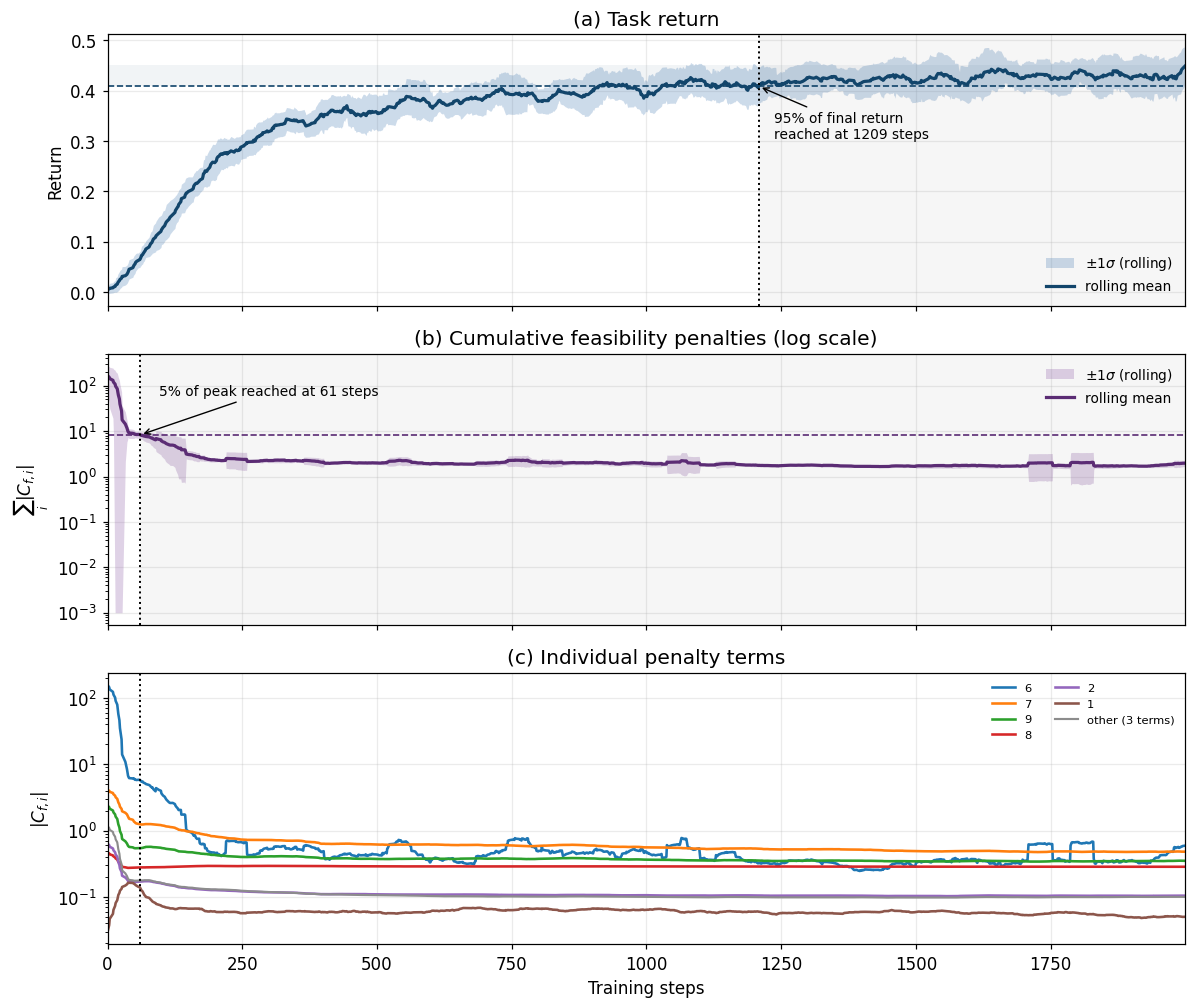

return reaches 95% of its final value at 1209 steps
penalties fall below 5% of peak at 61 steps (peak 165.9, final 1.97)


In [30]:
if have_rew:
    rs, rsd = roll_stats(rew)
    ps, psd = roll_stats(total_pen)

    r_final = rs[int(0.9 * len(rs)):].mean()
    r_thr = 0.95 * r_final
    r_step, _ = settle_step(step_r, rs, r_thr, below=False)

    p_peak = ps.max()
    p_thr = 0.05 * p_peak
    p_step, _ = settle_step(step_r, ps, p_thr, below=True)

    nrow = 3 if (mat is not None and len(terms) > 1) else 2
    fig, axes = plt.subplots(nrow, 1, figsize=(11, 3.1 * nrow), sharex=True)

    # ---------------- (a) return
    ax = axes[0]
    ax.fill_between(step_r, rs - rsd, rs + rsd, color="#4a7fb5", alpha=0.28, lw=0,
                    label="$\\pm 1\\sigma$ (rolling)")
    ax.plot(step_r, rs, color="#12456b", lw=2.1, label="rolling mean")
    ax.axhspan(r_thr, r_final + (r_final - r_thr), color="#12456b", alpha=0.06, lw=0)
    ax.axhline(r_thr, color="#12456b", ls="--", lw=1.1)
    ax.axvline(r_step, color="black", ls=":", lw=1.3)
    ax.axvspan(r_step, step_r.max(), color="0.5", alpha=0.07, lw=0)
    ax.annotate(f"95% of final return\nreached at {r_step:.0f} steps",
                xy=(r_step, r_thr), xytext=(10, -34), textcoords="offset points",
                fontsize=9, arrowprops=dict(arrowstyle="->", lw=0.9))
    ax.set_ylabel("Return")
    ax.legend(loc="lower right", fontsize=9)
    ax.set_title("(a) Task return")

    # ---------------- (b) total penalty
    ax = axes[1]
    lo = np.maximum(ps - psd, 1e-3)
    ax.fill_between(step_r, lo, ps + psd, color="#8e5ea8", alpha=0.28, lw=0,
                    label="$\\pm 1\\sigma$ (rolling)")
    ax.plot(step_r, ps, color="#5b2c74", lw=2.1, label="rolling mean")
    ax.set_yscale("log")
    ax.axhline(p_thr, color="#5b2c74", ls="--", lw=1.1)
    ax.axvline(p_step, color="black", ls=":", lw=1.3)
    ax.axvspan(p_step, step_r.max(), color="0.5", alpha=0.07, lw=0)
    ax.annotate(f"5% of peak reached at {p_step:.0f} steps",
                xy=(p_step, p_thr), xytext=(12, 26), textcoords="offset points",
                fontsize=9, arrowprops=dict(arrowstyle="->", lw=0.9))
    ax.set_ylabel("$\\sum_i |C_{f,i}|$")
    ax.legend(loc="upper right", fontsize=9)
    ax.set_title("(b) Cumulative feasibility penalties (log scale)")

    # ---------------- (c) per-term
    if nrow == 3:
        ax = axes[2]
        rank = np.argsort(-mat.mean(axis=1))
        names = list(terms.keys())
        cmap = plt.get_cmap("tab10")
        for k, i in enumerate(rank[:6]):
            ax.plot(step_r, smooth(mat[i]), lw=1.7, color=cmap(k % 10),
                    label=names[i].replace("_", " "))
        if len(rank) > 6:
            ax.plot(step_r, smooth(mat[rank[6:]].sum(axis=0)), lw=1.4, color="0.55",
                    label=f"other ({len(rank)-6} terms)")
        ax.set_yscale("log")
        ax.axvline(p_step, color="black", ls=":", lw=1.3)
        ax.set_ylabel("$|C_{f,i}|$")
        ax.set_title("(c) Individual penalty terms")
        ax.legend(fontsize=7.5, ncol=2, loc="upper right")

    axes[-1].set_xlabel("Training steps")
    axes[-1].set_xlim(step_r.min(), step_r.max())
    fig.tight_layout()
    savefig(fig, "fig09_training_curves")
    plt.show()

    print(f"return reaches 95% of its final value at {r_step:.0f} steps")
    print(f"penalties fall below 5% of peak at {p_step:.0f} steps "
          f"(peak {p_peak:.1f}, final {ps[-1]:.2f})")

saved fig09_training_curves_twin


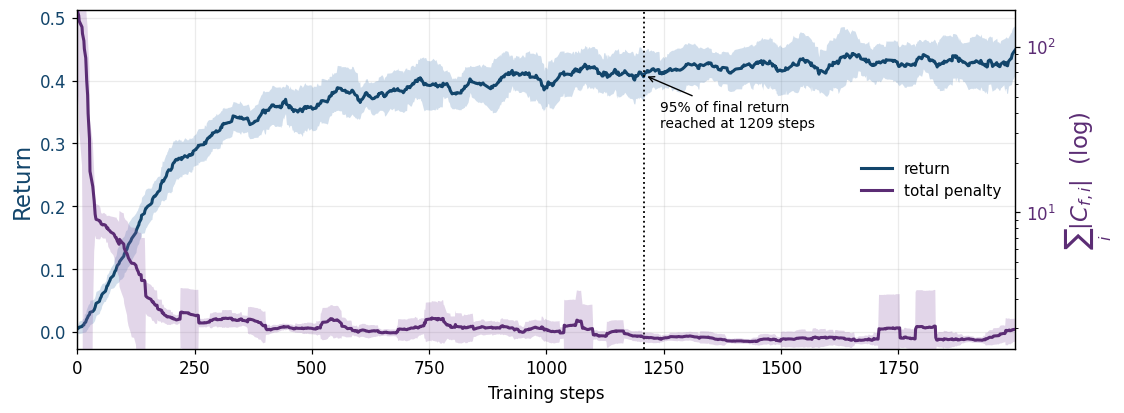

In [43]:
# corrected twin-axis variant, if the single-panel layout is needed for space
if have_rew:
    fig, ax1 = plt.subplots(figsize=(11, 4.0))
    ax1.fill_between(step_r, rs - rsd, rs + rsd, color="#4a7fb5", alpha=0.25, lw=0)
    l1, = ax1.plot(step_r, rs, color="#12456b", lw=2.0, label="return")
    ax1.axvline(r_step, color="black", ls=":", lw=1.2)
    ax1.annotate(f"95% of final return\nreached at {r_step:.0f} steps",
                xy=(r_step, r_thr), xytext=(10, -34), textcoords="offset points",
                fontsize=9, arrowprops=dict(arrowstyle="->", lw=0.9))
    ax1.set_xlabel("Training steps")
    ax1.set_ylabel("Return", color="#12456b", fontsize=15)
    ax1.tick_params(axis="y", labelcolor="#12456b")
    ax1.set_xlim(step_r.min(), step_r.max())

    ax2 = ax1.twinx()
    ax2.fill_between(step_r, np.maximum(ps - psd, 1e-3), ps + psd,
                     color="#8e5ea8", alpha=0.25, lw=0)
    l2, = ax2.plot(step_r, ps, color="#5b2c74", lw=2.0, label="total penalty")
    ax2.set_yscale("log")                     # no clipping: the peak stays visible
    ax2.set_ylabel("$\\sum_i |C_{f,i}|$  (log)", color="#5b2c74", fontsize=15)
    ax2.tick_params(axis="y", labelcolor="#5b2c74")
    ax2.set_ylim(ps.min()*0.9, ps.max())
    ax2.grid(False)

    ax1.legend(handles=[l1, l2], loc="center right", fontsize=10)
    savefig(fig, "fig09_training_curves_twin")
    plt.show()

In [32]:
print("figures written to:", OUT)
for f in sorted(os.listdir(OUT)):
    print("  ", f)

figures written to: /home/riccardo/Documents/guided-rl-jump/source/standalone/logs/rsl_rl/unitree_go1_jump/results/figures_paper
   fig09_training_curves.pdf
   fig09_training_curves.png
   fig09_training_curves_twin.pdf
   fig09_training_curves_twin.png
   fig10_feasible_region.pdf
   fig10_feasible_region.png
   fig10_feasible_region_binned.pdf
   fig10_feasible_region_binned.png
   fig10_feasible_region_scatter.pdf
   fig10_feasible_region_scatter.png
   fig11_distance_tracking.pdf
   fig11_distance_tracking.png
   fig12_height_maps.pdf
   fig12_height_maps.png
   fig13_yaw_cartesian.pdf
   fig13_yaw_cartesian.png
   fig13_yaw_polar.pdf
   fig13_yaw_polar.png
   fig17_forward_policy.pdf
   fig17_forward_policy.png
